In [ ]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [9]:

# -----------------------------------------
# Function to read a 4-season dataset
# -----------------------------------------
def read_seasonal_dataset(files, value_col="z_mean"):
    """
    Read 4 seasonal .tab files and return a dictionary of xarrays.
    """
    seasons = ["DJF","MAM","JJA","SON"]
    seasonal_data = {}

    for season, f in zip(seasons, files):
        df = pd.read_csv(f, sep="\s+")
        da = df.pivot(index="lat", columns="lon", values=value_col)
        seasonal_data[season] = xr.DataArray(da.values,
                                             coords={"lat":da.index,"lon":da.columns},
                                             dims=["lat","lon"])
    return seasonal_data

# -----------------------------------------
# Compute zonal mean for each season
# -----------------------------------------
def compute_zonal_mean(seasonal_data):
    zonal_means = {}
    for season, da in seasonal_data.items():
        zonal_mean = da.mean(dim="lon")
        zonal_means[season] = pd.Series(zonal_mean.values, index=da.lat)
    return zonal_means

# -----------------------------------------
# Plot zonal mean for multiple datasets
# -----------------------------------------
def plot_multiple_zonal_means(all_zonal_means, dataset_names, title=None):
    plt.figure(figsize=(10,6))
#     seasons = ["DJF","MAM","JJA","SON"]
    seasons = ["JJA"]
    colors = ["C0","C1","C2","C3"]

    for name, zonal_means in zip(dataset_names, all_zonal_means):
        for season, color in zip(seasons, colors):
            plt.plot(zonal_means[season].index, zonal_means[season].values,
                     label=f"{name} {season}", alpha=0.8)

    plt.xlabel("Latitude [deg]")
    plt.ylabel("Tropopause Height [km]")
    if title:
        plt.title(title)
    plt.grid(True)
    plt.legend(fontsize=8)
    plt.show()

# -----------------------------------------
# Main workflow
# -----------------------------------------

datasets = ["wmo_1st", "wmo_2nd", "clp", "dyn"]
all_zonal_means = []

for ds_name in datasets:
    # Path to the 4 seasonal .tab files
    files = [
        f"./Seasonal_Data/era5_{ds_name}_DJF.tab",
        f"./Seasonal_Data/era5_{ds_name}_MAM.tab",
        f"./Seasonal_Data/era5_{ds_name}_JJA.tab",
        f"./Seasonal_Data/era5_{ds_name}_SON.tab"
    ]

    seasonal_data = read_seasonal_dataset(files)
    zonal_means = compute_zonal_mean(seasonal_data)
    all_zonal_means.append(zonal_means)


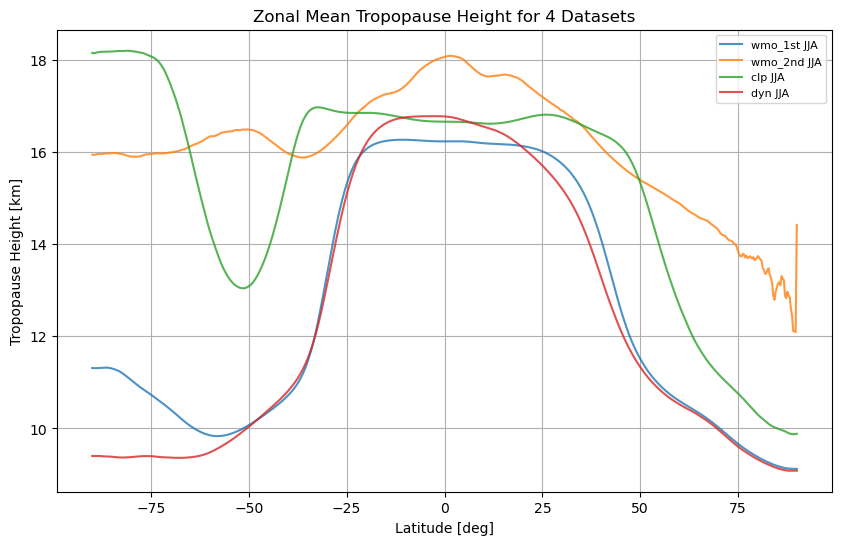

In [10]:
# Plot all 4 datasets together
plot_multiple_zonal_means(all_zonal_means, datasets, title="Zonal Mean Tropopause Height for 4 Datasets")